### Load the master dataset ###

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv(r"C:\Users\shiv_\OneDrive\Desktop\AI-ScamShield\data\processed\master_dataset.csv")
df.head()

,label,message,source,scam_type
0,legit,"Go until jurong point, crazy.. Available only ...",sms,none
1,legit,Ok lar... Joking wif u oni...,sms,none
2,scam,Free entry in 2 a wkly comp to win FA Cup fina...,sms,unknown
3,legit,U dun say so early hor... U c already then say...,sms,none
4,legit,"Nah I don't think he goes to usf, he lives aro...",sms,none


#### Analysis the message lengths ####

In [5]:
df["message_length"] = df["message"].apply(len)
df["word_count"] = df["message"].apply(lambda x: len(str(x).split()))

df[["message_length", "word_count"]].describe()

,message_length,word_count
count,4.901900e+04,4.901900e+04
mean,2.228850e+03,3.695816e+02
std,7.700709e+04,1.593985e+04
min,1.000000e+00,0.000000e+00
25%,2.635000e+02,4.400000e+01
50%,1.239000e+03,2.010000e+02
75%,2.713000e+03,4.120000e+02
max,1.703669e+07,3.527576e+06


### Histplot: Scam VS Legit ###

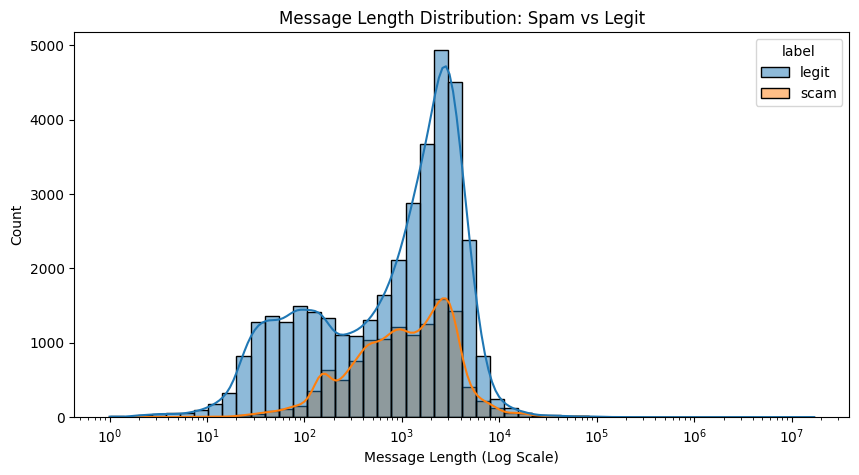

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True, log_scale=(True, False))
plt.title('Message Length Distribution: Spam vs Legit')
plt.xlabel('Message Length (Log Scale)')
plt.savefig('../notebooks/figures/message_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Boxplots: Scam VS Legit ###

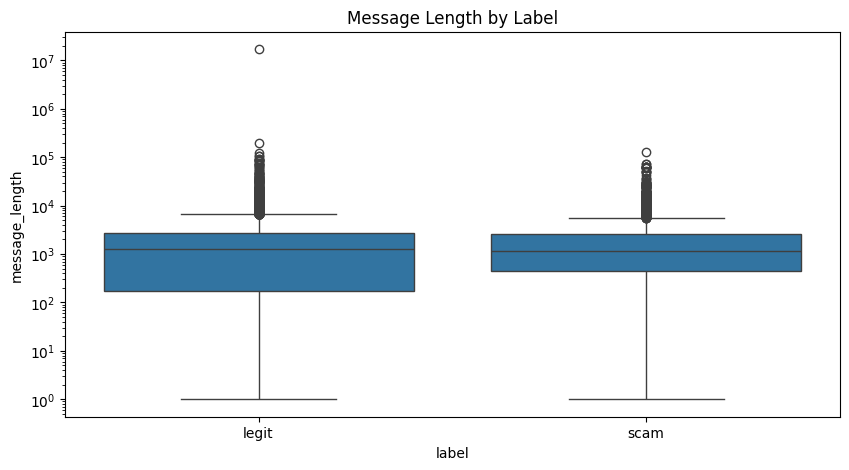

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='label', y='message_length')
plt.yscale('log')
plt.title('Message Length by Label')
plt.savefig('../notebooks/figures/message_length_by_label.png', dpi=150, bbox_inches='tight')
plt.show()


### Word Count by Scam Type ###

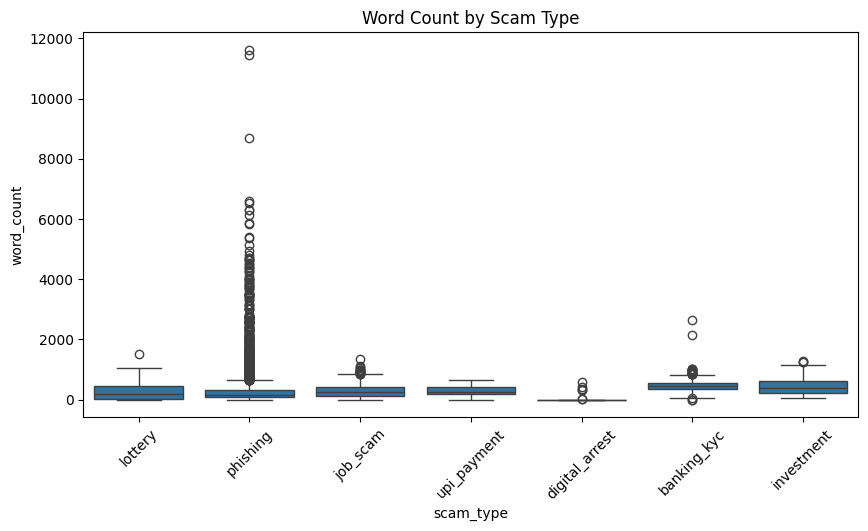

In [9]:
subset = df[~df['scam_type'].isin(['none', 'unknown'])]

plt.figure(figsize=(10, 5))
sns.boxplot(data=subset, x='scam_type', y='word_count')
plt.xticks(rotation=45)
plt.title('Word Count by Scam Type')
plt.savefig('../notebooks/figures/word_count_by_scam_type.png', dpi=150, bbox_inches='tight')
plt.show()
plt.show()

### Checking the message length by source ###

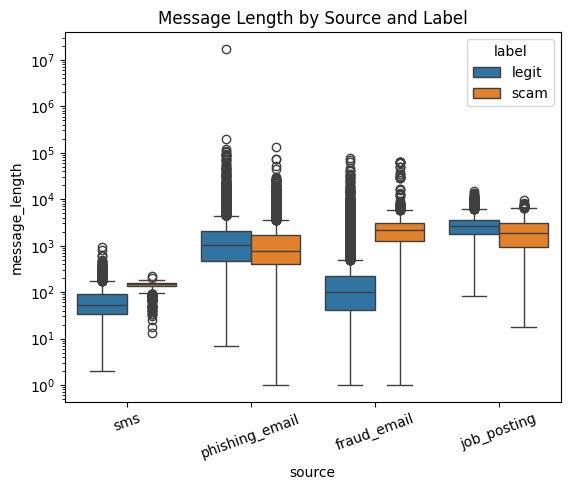

In [10]:
plt.Figure(figsize=(10, 5))
sns.boxplot(data=df, x='source', y='message_length', hue='label')
plt.yscale('log')
plt.title('Message Length by Source and Label')
plt.xticks(rotation=20)
plt.savefig('../notebooks/figures/message_length_by_source_and_label.png', dpi=150, bbox_inches='tight')
plt.show()

### Text Cleaning ###

In [6]:
import re 
import html 

def clean_text_basic(text):
    text = str(text).lower()
    text = html.unescape(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text 

df['clean_message'] = df['message'].apply(clean_text_basic)
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


### Wordloud and stopwords ###

In [7]:
from wordcloud import WordCloud 
from nltk.corpus import stopwords 
import nltk 
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shiv_\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Word clouds: Scam VS Legit ###

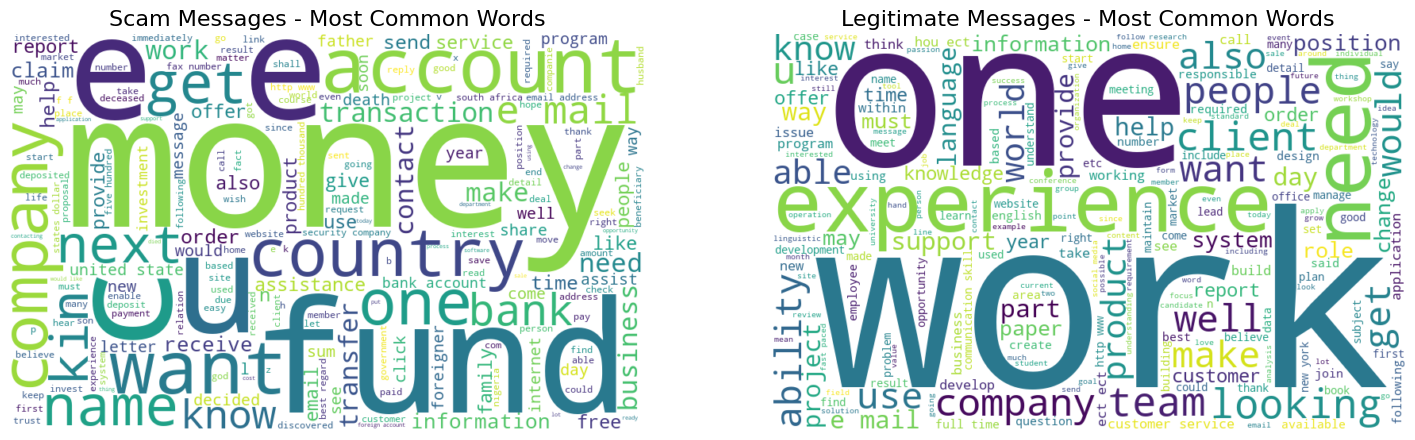

In [9]:
scam_text = ' '.join(df[df['label'] == 'scam']['clean_message'])
legit_text = ' '.join(df[df['label'] == 'legit']['clean_message'])

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

wc_scam = WordCloud(width=800, height=500, background_color='white', stopwords=stop_words).generate(scam_text)
axes[0].imshow(wc_scam, interpolation='bilinear')
axes[0].set_title('Scam Messages - Most Common Words', fontsize=16)
axes[0].axis('off')

wc_legit = WordCloud(width=800, height=500, background_color='white', stopwords=stop_words).generate(legit_text)
axes[1].imshow(wc_legit, interpolation='bilinear')
axes[1].set_title('Legitimate Messages - Most Common Words', fontsize=16)
axes[1].axis('off')

plt.savefig('../notebooks/figures/worldcloud_scam_vs_legit.png', dpi=150, bbox_inches='tight')
plt.show()


### Top 20 words as a bar chart ###

In [10]:
from collections import Counter 

def get_top_words(text_series, n=20):
    all_words = ' '.join(text_series).split()
    all_words = [w for w in all_words if w not in stop_words and len(w) > 2]
    return Counter(all_words).most_common(n)

top_scam_words = get_top_words(df[df['label']=='scam']['clean_message'])
top_legit_words = get_top_words(df[df['label']=='legit']['clean_message'])

print("Top Scam Words:", top_scam_words)
print("Top Legit Words:", top_legit_words)

Top Scam Words: [('money', 13679), ('account', 9122), ('bank', 8679), ('business', 8527), ('company', 7901), ('email', 7632), ('please', 7336), ('one', 6332), ('mail', 6030), ('information', 5975), ('free', 5746), ('com', 5679), ('million', 5620), ('get', 5478), ('transaction', 5202), ('time', 5197), ('country', 5154), ('name', 4942), ('next', 4838), ('fund', 4827)]
Top Legit Words: [('work', 39487), ('experience', 37274), ('team', 32896), ('new', 27512), ('company', 24909), ('business', 24341), ('time', 21621), ('one', 20450), ('people', 18463), ('skills', 17943), ('development', 17899), ('enron', 17840), ('language', 17378), ('working', 17306), ('management', 17189), ('university', 16827), ('customer', 16218), ('also', 16158), ('information', 15754), ('services', 15604)]


### Bigrams ###

In [12]:
from sklearn.feature_extraction.text import CountVectorizer 

def get_top_ngrams(text_series, n_gram=2, top_n=20):
    vec = CountVectorizer(ngram_range=(n_gram, n_gram), stop_words='english').fit(text_series)
    bag_of_words = vec.transform(text_series)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_n]

scam_bigrams = get_top_ngrams(df[df['label']=='scam']['clean_message'], n_gram=2, top_n=20)
legit_bigrams = get_top_ngrams(df[df['label']=='legit']['clean_message'], n_gram=2, top_n=20)

print("Top scam bigrams:", scam_bigrams)
print("Top legit bigrams:", legit_bigrams)


Top scam bigrams: [('united states', np.int64(1533)), ('security company', np.int64(1470)), ('bank account', np.int64(1395)), ('http www', np.int64(1388)), ('email address', np.int64(1271)), ('south africa', np.int64(1136)), ('states dollars', np.int64(1070)), ('million dollars', np.int64(999)), ('million thousand', np.int64(937)), ('best regards', np.int64(899)), ('sum million', np.int64(891)), ('transfer money', np.int64(779)), ('telephone fax', np.int64(750)), ('million united', np.int64(713)), ('foreign account', np.int64(708)), ('plane crash', np.int64(681)), ('total sum', np.int64(668)), ('dear sir', np.int64(663)), ('fax number', np.int64(661)), ('dear friend', np.int64(635))]
Top legit bigrams: [('customer service', np.int64(5134)), ('hou ect', np.int64(5001)), ('ect ect', np.int64(4867)), ('years experience', np.int64(3815)), ('communication skills', np.int64(3663)), ('http www', np.int64(3334)), ('new york', np.int64(3304)), ('social media', np.int64(3046)), ('fast paced', np

### Class balance & scam_type distribution ###

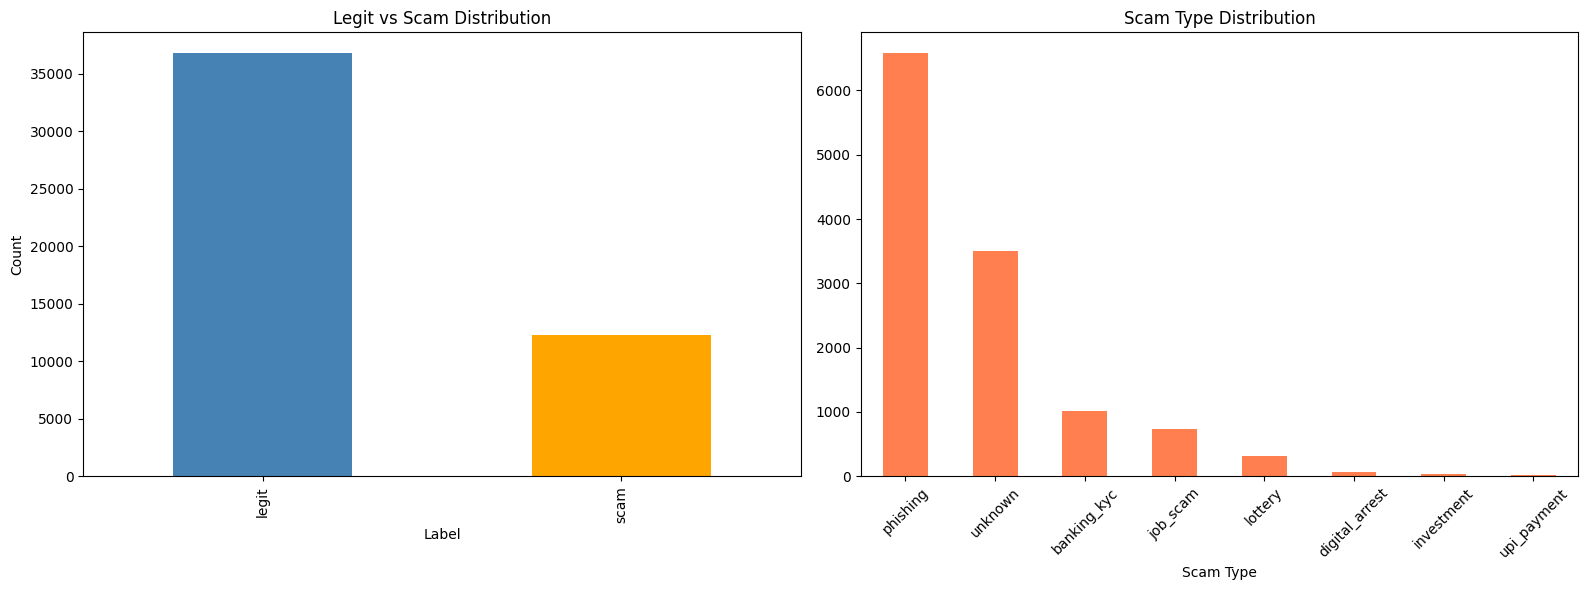

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'orange'])
axes[0].set_title('Legit vs Scam Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

scam_only = df[df['scam_type'] != 'none']
scam_only['scam_type'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Scam Type Distribution')
axes[1].set_xlabel('Scam Type')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../notebooks/figures/class_and_scamtype_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Cross-tab: source vs label ###

In [14]:
pd.crosstab(df['source'], df['label'])

label,legit,scam
source,,
fraud_email,5913,4334
job_posting,15348,718
phishing_email,10979,6558
sms,4516,653


### Full Text Preprocessing ###

In [8]:
import re 
import html
import nltk
from nltk.corpus import stopwords 
from nltk.stem import PorterStemmer 

nltk.download('stopwords')
nltk.download('punkt')

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

custom_stopwords = {'hou', 'ect', 'enron', 'nbsp'}
stop_word = stop_words.union(custom_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shiv_\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shiv_\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [11]:
def preprocess_text(text):
    text = str(text).lower()
    text = html.unescape(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text).strip()
    
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    words = [stemmer.stem(w) for w in words]
    
    return ' '.join(words)   

In [12]:
df['processed_message'] = df['message'].apply(preprocess_text)
df[['message', 'processed_message']].sample(5)

,message,processed_message
34396,Global Marketing Manager Axonix is a global mo...,global market manag axonix global mobil advert...
12589,kbcs-98 call for papers k b c s-98 call for pa...,kbc call paper call paper intern confer knowle...
3618,Pls go there today &lt;#&gt; . I dont want an...,pl today dont want excus
9988,offsite it was a great event all around . the ...,offsit great event around accommod could nicer...
13725,1) Fight The Risk of Cancer!\nhttp://www.adcli...,fight risk cancer slim guarante lose lb day ge...


In [13]:
df.to_csv('../data/processed/master_dataset_processed.csv', index=False)